# package_lab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_lab 
import package_DBR

from importlib import reload
package_lab = reload(package_lab)

from package_DBR import myRound, SelectPath_RT, Delay_RT, Bode, Process
from package_lab import LL_RT, IMCTuning, Margin

# LL_RT()

In [2]:
help(LL_RT)

Help on function LL_RT in module package_lab:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "FO_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "FO_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

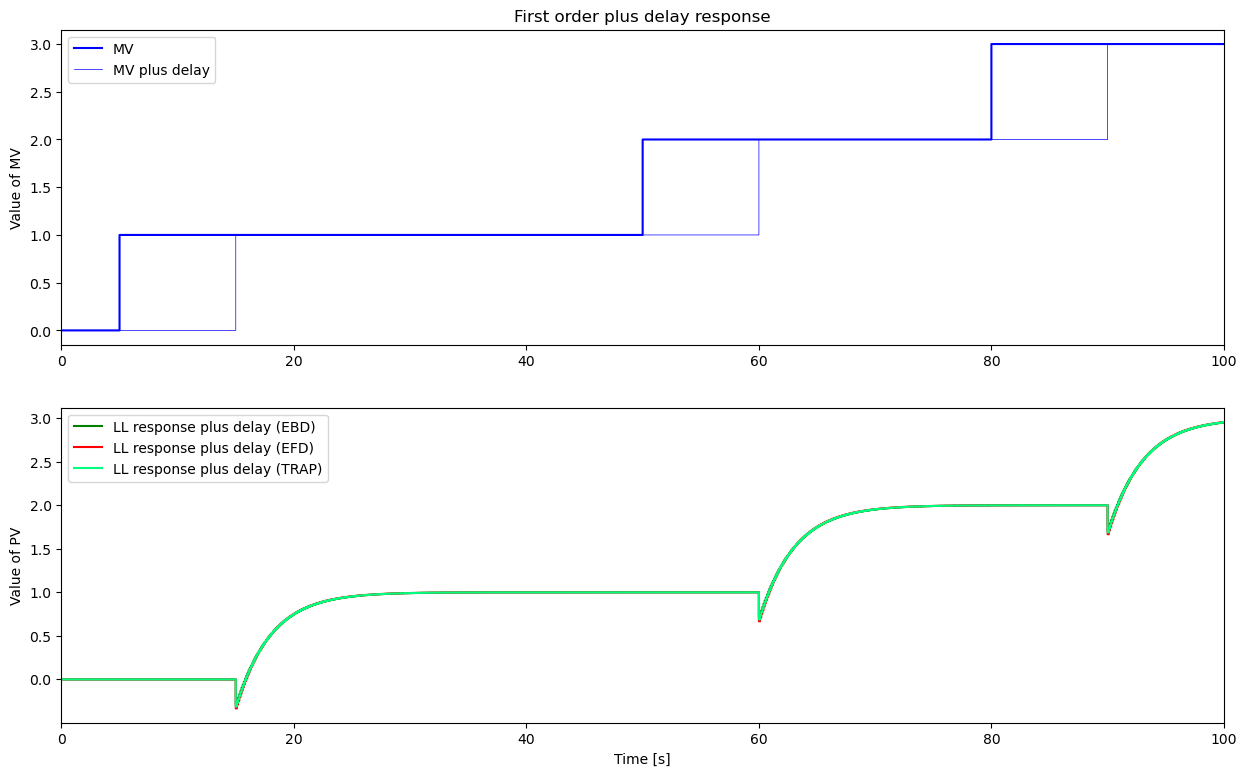

In [3]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlead = -1
Tlag = 3
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EBD,0,'EBD')
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('First order plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='LL response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'r',label='LL response plus delay (EFD)',where='post')
plt.step(t,PV_TRAP,'springgreen',label='LL response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# IMC TUNING

In [4]:
# Parameters for input-output dynamic
Kp = 0.375
T1p = 128.82 
T2p = 73.34 
thetap = 9.30 

# Parameters PID controller
gamma = 0.9                                # A faire : Discuter variation de gamma
Kc, Ti, Td = IMCTuning(Kp,T1p,T2p,thetap,gamma, process='SOPDT')

print("Kc = ",Kc)
print("Ti = ",Ti)
print("Td = ",Td)

Kc =  4.304550801939773
Ti =  202.16
Td =  46.73357142857142


# Margin

In [ ]:
P = Process({})

Kp = 0.42
Tlag1 = 93.5
Tlag2 = 0
theta = 7.4
T1p = 119 # Tg
T2p = 6 # Tu

P.parameters['Kp'] = Kp
P.parameters['Tlag1'] = Tlag1
P.parameters['Tlag2'] = Tlag2
P.parameters['theta'] = theta

Kc, Ti, Td = IMCTuning(Kp,T1p,T2p,thetap,gamma, 'SOPDT')
alpha = 0.9

C = PID({})
C.parameters['Kc'] = Kc
C.parameters['Ti'] = Ti
C.parameters['Td']= Td
C.parameters['Tfd'] = alpha *Td # temps dérivation après filtrage


omega = np.logspace(-3,1,10000)

Ps = Bode(P,omega,Show=False)

Margin(Ps,C,omega)